<a href="https://colab.research.google.com/github/ankush-w17/Address-Book-System/blob/main/IMDB_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q tensorflow groq
!pip install -q tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 6.7 MB/s eta 0:00:00


In [3]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from groq import Groq
from tqdm import tqdm
import time



In [4]:
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")

In [5]:
VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 64
LSTM_UNITS = 64
DROPOUT_RATE = 0.3
LEARNING_RATE = 3e-4
BATCH_SIZE = 32
EPOCHS = 5
TEACHER_SAMPLES = 300


In [6]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(seq):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in seq])

x_train_pad = pad_sequences(x_train, maxlen=MAX_LEN)
x_test_pad = pad_sequences(x_test, maxlen=MAX_LEN)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
client = Groq(api_key=GROQ_API_KEY)

def groq_label(text):
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "system", "content": "Reply ONLY with 1 for positive or 0 for negative."},
            {"role": "user", "content": text}
        ],
        temperature=0
    )
    content = response.choices[0].message.content.strip()
    return int(content.split()[0])


In [8]:
teacher_labels = []

for i in tqdm(range(TEACHER_SAMPLES), desc="Labeling with Groq", unit="review"):
    teacher_labels.append(groq_label(decode_review(x_train[i])))
    time.sleep(0.3)

teacher_labels = np.array(teacher_labels)


Labeling with Groq: 100%|██████████| 300/300 [14:53<00:00,  2.98s/review]


In [9]:
x_distill = np.concatenate([
    x_train_pad[:TEACHER_SAMPLES],
    x_train_pad[TEACHER_SAMPLES:TEACHER_SAMPLES*2]
])

y_distill = np.concatenate([
    teacher_labels,
    y_train[TEACHER_SAMPLES:TEACHER_SAMPLES*2]
])


In [10]:
def build_student():
    model = models.Sequential([
        layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
        layers.SpatialDropout1D(DROPOUT_RATE),
        layers.Bidirectional(
            layers.LSTM(
                LSTM_UNITS,
                dropout=DROPOUT_RATE,
                recurrent_dropout=0.15
            )
        ),
        layers.Dense(32, activation="relu"),
        layers.Dropout(DROPOUT_RATE),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )
    return model


In [11]:
model = build_student()

model.fit(
    x_distill,
    y_distill,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 749ms/step - accuracy: 0.5044 - loss: 0.6937 - val_accuracy: 0.5333 - val_loss: 0.6919
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 710ms/step - accuracy: 0.5652 - loss: 0.6907 - val_accuracy: 0.5333 - val_loss: 0.6910
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 735ms/step - accuracy: 0.5665 - loss: 0.6897 - val_accuracy: 0.5333 - val_loss: 0.6901
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 770ms/step - accuracy: 0.5334 - loss: 0.6896 - val_accuracy: 0.5333 - val_loss: 0.6891
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 735ms/step - accuracy: 0.5653 - loss: 0.6828 - val_accuracy: 0.5333 - val_loss: 0.6885


In [12]:
model.fit(
    x_train_pad[:10000],
    y_train[:10000],
    batch_size=32,
    epochs=2,
    verbose=1
)


Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.6039 - loss: 0.6573
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 347s 1s/step - accuracy: 0.8405 - loss: 0.4641


In [13]:
idx = 41
raw = decode_review(x_test[idx])
lstm_pred = model.predict(x_test_pad[idx:idx+1])[0][0]
groq_pred = groq_label(raw)

print(raw[:120])
print("LSTM:", "Positive" if lstm_pred > 0.5 else "Negative", round(lstm_pred, 3))
print("Groq:", "Positive" if groq_pred == 1 else "Negative")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step
? little ? needs to fly is another in the remarkable body of ? ? ? work that is without ? having recently ? it on dvd ne
LSTM: Positive 0.908
Groq: Positive


In [14]:
import random
import numpy as np
import matplotlib.pyplot as plt


In [15]:
indices = random.sample(range(len(x_test)), 50)

true_labels = []
groq_labels = []
lstm_labels = []

for idx in indices:
    text = decode_review(x_test[idx])
    true_labels.append(y_test[idx])
    groq_labels.append(groq_label(text))
    pred = model.predict(x_test_pad[idx:idx+1], verbose=0)[0][0]
    lstm_labels.append(1 if pred > 0.5 else 0)

true_labels = np.array(true_labels)
groq_labels = np.array(groq_labels)
lstm_labels = np.array(lstm_labels)


In [16]:
groq_accuracy = np.mean(groq_labels == true_labels)
lstm_accuracy = np.mean(lstm_labels == true_labels)

labels = ["Groq (Teacher)", "LSTM (Student)"]
accuracies = [groq_accuracy, lstm_accuracy]


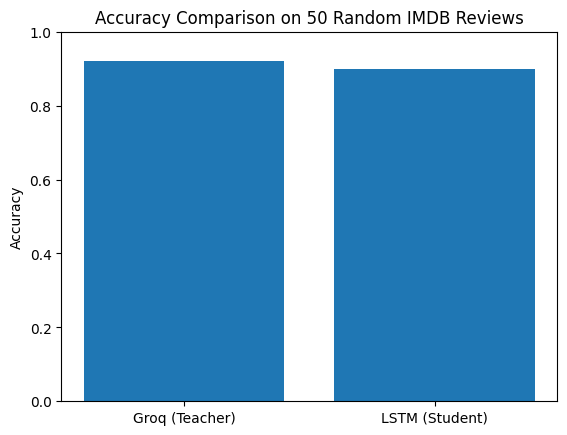

In [17]:
plt.figure()
plt.bar(labels, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison on 50 Random IMDB Reviews")
plt.show()


In [18]:
import json
import random

indices_5 = random.sample(range(len(x_test)), 5)

raw_output = []

for idx in indices_5:
    raw_output.append({
        "review_id": int(idx),
        "review_tokens": x_test[idx],
        "label": int(y_test[idx])
    })

print(json.dumps(raw_output, indent=4))


[
    {
        "review_id": 7078,
        "review_tokens": [
            1,
            13,
            510,
            14,
            22,
            4,
            96,
            134,
            8737,
            610,
            367,
            19,
            4,
            1163,
            7,
            4,
            22,
            9,
            55,
            52,
            935,
            628,
            2,
            17,
            3060,
            2295,
            2,
            16,
            87,
            12,
            166,
            72,
            594,
            48,
            27,
            1613,
            9,
            618,
            4,
            172,
            11,
            147,
            113,
            549,
            18,
            4,
            3430,
            7,
            265,
            10,
            10,
            13,
            16,
            1555,
            19,
            4,
            2373,
         

In [19]:


movies = []

for idx in indices_5:
    review = decode_review(x_test[idx])
    lstm_prob = model.predict(x_test_pad[idx:idx+1], verbose=0)[0][0]
    groq_pred = groq_label(review)

    movies.append({
        "review_id": int(idx),
        "review_text": review[:500],
        "true_label": "Positive" if y_test[idx] == 1 else "Negative",
        "lstm_prediction": {
            "label": "Positive" if lstm_prob > 0.5 else "Negative",
            "confidence": round(float(lstm_prob), 3)
        },
        "groq_prediction": "Positive" if groq_pred == 1 else "Negative"
    })

print(json.dumps(movies, indent=4))


[
    {
        "review_id": 7078,
        "review_text": "? i enjoyed this film the way these mutants looked along with the tone of the film is very good plus david ? as philip k ? was great it makes me wonder if his personality is exactly the same in real life except for the killings of course br br i was impressed with the creatures for this film although this movie probably had a somewhat low budget the mutants creatures monsters looked great especially from 1990 this is definitely a unique film and not crap it makes me want to go find a read the ? ",
        "true_label": "Positive",
        "lstm_prediction": {
            "label": "Positive",
            "confidence": 0.781
        },
        "groq_prediction": "Positive"
    },
    {
        "review_id": 13487,
        "review_text": "? this movie was so cool i saw it on a friday night with a couple of my friends while the first credits were rolling we saw that ? films had made this movie they are the ones that made that stupid

In [28]:
import random
import json
import re
from groq import Groq

client = Groq(api_key=GROQ_API_KEY)

def groq_sarcasm_analysis(review_text):
    prompt = (
        "You are analyzing a single IMDB movie review to infer the reviewer's intent, tone, and any explicitly mentioned movie metadata.\n\n"
        "PRIMARY OBJECTIVE:\n"
        "Determine whether the reviewer is being sarcastic, based on intent and rhetorical structure, not emotional intensity alone.\n\n"
        "DEFINITION OF SARCASM:\n"
        "Sarcasm is the intentional use of praise, humor, or understatement to mock, ridicule, or invert the reviewer's true opinion.\n\n"
        "SARCASM REQUIREMENTS (ALL must be satisfied):\n"
        "- Clear ironic or mock-positive framing\n"
        "- Intentional contrast between wording and actual sentiment\n"
        "- Reviewer intent to ridicule or mock, not merely criticize\n\n"
        "DO NOT classify as sarcasm if the review is:\n"
        "- Straightforward criticism or praise\n"
        "- Angry ranting without irony\n"
        "- Analytical or descriptive evaluation\n"
        "- Mixed or nuanced opinion without mockery\n"
        "- Emotional exaggeration without ironic intent\n\n"
        "SARCASM TYPES:\n"
        "- positive: affectionate irony, camp appreciation, playful mock praise\n"
        "- negative: ridicule, dismissive irony, mocking criticism\n"
        "- none: literal, sincere, or straightforward tone\n\n"
        "CRITICAL METADATA EXTRACTION RULES - READ CAREFULLY:\n"
        "- Extract movie name ONLY if the EXACT title appears as quoted text or proper noun in the review\n"
        "- Extract release year ONLY if a 4-digit year (1800-2100) is explicitly stated in the review\n"
        "- NEVER guess, infer, assume, or use external knowledge\n"
        "- NEVER include movie_name if you're uncertain or if it's implied but not stated\n"
        "- NEVER include movie_year if you're uncertain or if it's implied but not stated\n"
        "- If movie name is absent or uncertain: COMPLETELY OMIT the \"movie_name\" key from JSON\n"
        "- If movie year is absent or uncertain: COMPLETELY OMIT the \"movie_year\" key from JSON\n"
        "- When in doubt, OMIT the field - do NOT include it with null, empty string, or placeholder values\n\n"
        "OUTPUT RULES (MANDATORY):\n"
        "- Output MUST be valid JSON\n"
        "- Output MUST contain ONLY the JSON object\n"
        "- Do NOT include explanations, markdown, or extra text\n"
        "- Do NOT wrap the JSON in code blocks\n"
        "- Do NOT include trailing commas\n"
        "- Do NOT include movie_name or movie_year keys if values are unavailable\n\n"
        "OUTPUT FORMAT (STRICT):\n"
        "{\n"
        "  \"movie_name\": \"exact title from review\" (OMIT this entire line if not explicitly present),\n"
        "  \"movie_year\": year_as_integer (OMIT this entire line if not explicitly present),\n"
        "  \"sarcasm_type\": \"positive\" | \"negative\" | \"none\",\n"
        "  \"sarcasm_confidence\": number between 0.0 and 1.0,\n"
        "  \"reviewer_sentiment\": \"positive\" | \"neutral\" | \"negative\",\n"
        "  \"reasoning\": string\n"
        "}\n\n"
        "EXAMPLE 1 - Movie mentioned:\n"
        "Review: \"The Godfather (1972) is a masterpiece\"\n"
        "Output: {\"movie_name\": \"The Godfather\", \"movie_year\": 1972, \"sarcasm_type\": \"none\", ...}\n\n"
        "EXAMPLE 2 - Movie NOT mentioned:\n"
        "Review: \"This film was terrible\"\n"
        "Output: {\"sarcasm_type\": \"none\", ...} (NO movie_name or movie_year keys)\n\n"
        "EXAMPLE 3 - Only name mentioned:\n"
        "Review: \"Inception blew my mind\"\n"
        "Output: {\"movie_name\": \"Inception\", \"sarcasm_type\": \"none\", ...} (NO movie_year key)\n\n"
        "Analyze the following review and respond ONLY with the JSON object:\n\n"
        f"{review_text}"
    )

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )

    raw = response.choices[0].message.content.strip()
    match = re.search(r"\{.*\}", raw, re.DOTALL)

    if not match:
        return {
            "sarcasm_type": "none",
            "sarcasm_confidence": 0.0,
            "reviewer_sentiment": "neutral",
            "reasoning": ""
        }

    try:
        parsed = json.loads(match.group())

        if "movie_name" in parsed:
            if not isinstance(parsed["movie_name"], str) or not parsed["movie_name"].strip():
                del parsed["movie_name"]

        if "movie_year" in parsed:
            if not isinstance(parsed["movie_year"], int) or parsed["movie_year"] < 1800 or parsed["movie_year"] > 2100:
                del parsed["movie_year"]

        return parsed
    except json.JSONDecodeError:
        return {
            "sarcasm_type": "none",
            "sarcasm_confidence": 0.0,
            "reviewer_sentiment": "neutral",
            "reasoning": ""
        }

indices = random.sample(range(len(x_test)), 5)

results = []

for idx in indices:
    review_text = decode_review(x_test[idx])
    analysis = groq_sarcasm_analysis(review_text)

    results.append({
        "review_id": int(idx),
        "review_text": review_text[:500],
        "true_label": "positive" if y_test[idx] == 1 else "negative",
        "analysis": analysis
    })

print(json.dumps(results, indent=4))

[
    {
        "review_id": 1058,
        "review_text": "? i really love action adventure films and this is one of the best of course we love the stars of this genre bruce willis sly stallone clint eastwood kurt russell arnold ? and the rest but its the story that really counts the best are somewhat ? but we can tolerate those that are a little over the top as in the comic book style of action the more twists and turns the more dire situations the heroes are involved in and the more shocking moments in the film the more we action adventure fans enjoy ",
        "true_label": "positive",
        "analysis": {
            "movie_name": "In the Line of Fire",
            "sarcasm_type": "negative",
            "sarcasm_confidence": 0.8,
            "reviewer_sentiment": "positive",
            "reasoning": "The review uses mock-positive framing, praising the film's elements, but the reviewer's intent is to ridicule the clich\u00e9s of the action-adventure genre, specifically the 'comic 